In [ ]:
!pip install numpy==1.26.4




  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.3 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-text 2.18.1 requires tensorflow<2.19,>=2.18.0, but you have tensorflow 2.19.0 which is incompatible.
tensorflow-decision-forests 1.11.0 requires tensorflow==2.18.0, but you have tensorflow 2.19.0 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompatible.
tf-keras 2.18.0 requires tensorflow<2.19,>=2.18, but you have tensorflow 2.19.0 which is incompatible.
ydf 0.11.0 requires protobuf<6.0.0,>=5.29.1, but you have protobuf 4.25.7 which is incompatible.


In [ ]:
!pip install --upgrade mediapipe tensorflow


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset shape: (9679, 63), Labels shape: (9679,)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
242/242 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.0517 - loss: 3.0538 - val_accuracy: 0.0584 - val_loss: 3.0317
Epoch 2/50
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0695 - loss: 3.0254 - val_accuracy: 0.0940 - val_loss: 2.9902
Epoch 3/50
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0914 - loss: 2.9781 - val_accuracy: 0.1023 - val_loss: 2.9110
Epoch 4/50
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1254 - loss: 2.8835 - val_accuracy: 0.2583 - val_loss: 2.7280
Epoch 5/50
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1619 - loss: 2.7471 - val_accuracy: 0.2459 - val_loss: 2.5784
Epoch 6/50
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2043 - loss: 2.6069 - val_accuracy: 0.2980 - val_loss: 2.4397
Epoch 7/50
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2393 - loss: 2.4774 - val_accuracy: 0.3693 - val_loss: 2.2642
Epoch 8/50
242/242 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2643 - loss: 2.3839 - val_accuracy: 0.

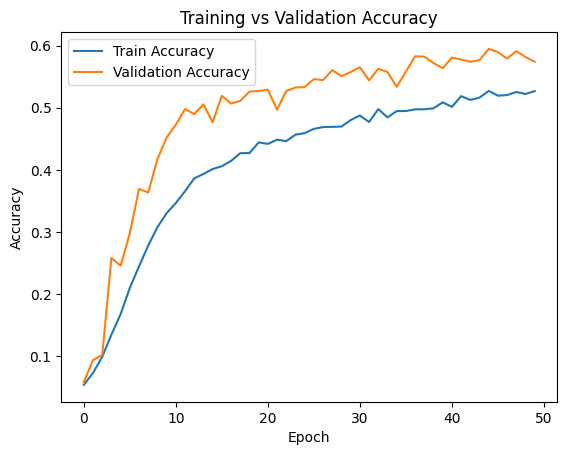

In [ ]:

!pip install mediapipe
!pip install tensorflow
!pip install scikit-learn

import mediapipe as mp
import numpy as np
import cv2
import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from google.colab import drive

# 3. MONTAR GOOGLE DRIVE
drive.mount('/content/drive')

# Ruta del dataset
dataset_dir = '/content/drive/MyDrive/dataset'  # Aquí debes tener carpetas train/ validation/ test/

# landmarks de las imagenes
mp_hands = mp.solutions.hands

def extract_hand_landmarks(image_path):
    image = cv2.imread(image_path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    with mp_hands.Hands(static_image_mode=True, max_num_hands=1) as hands:
        results = hands.process(image_rgb)
        if results.multi_hand_landmarks:
            landmarks = []
            for lm in results.multi_hand_landmarks[0].landmark:
                landmarks.extend([lm.x, lm.y, lm.z])
            return landmarks
        else:
            return None

# lectura de datos para train, val, y test
X = []
y = []

for split in ['train', 'validation', 'test']:
    split_path = os.path.join(dataset_dir, split)
    for label in os.listdir(split_path):
        label_path = os.path.join(split_path, label)
        if os.path.isdir(label_path):
            for img_name in os.listdir(label_path):
                img_path = os.path.join(label_path, img_name)
                landmarks = extract_hand_landmarks(img_path)
                if landmarks:
                    X.append(landmarks)
                    y.append(label)

X = np.array(X)
y = np.array(y)

print(f'Dataset shape: {X.shape}, Labels shape: {y.shape}')

# etiquetas
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)


X_train, X_val, y_train, y_val = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# creacion de modelos
model = Sequential([
    Dense(128, activation='relu', input_shape=(63,)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(len(np.unique(y_encoded)), activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# entrenamiento del modelo
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size=32)

# el export
model.save('/content/drive/MyDrive/modelo_mediapipe_letras.h5')
import pickle
with open('/content/drive/MyDrive/label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)


plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.show()
